# Loading, Analysis and Cleaning of the Data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/king_country_houses_aa.csv")
df_raw = df.copy() #we are using this raw df for the initial analysis, so df will be the clean df.

In [2]:
df_raw.shape

(21613, 21)

In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [4]:
df_raw.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [5]:
df_raw.describe().round(2)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00
mean,4.580302e+09,540088.14,3.37,2.11,2079.90,15106.97,1.49,0.01,0.23,3.41,7.66,1788.39,291.51,1971.01,84.40,98077.94,47.56,-122.21,1986.55,12768.46
std,2.876566e+09,367127.20,0.93,0.77,918.44,41420.51,0.54,0.09,0.77,0.65,1.18,828.09,442.58,29.37,401.68,53.51,0.14,0.14,685.39,27304.18
min,1.000102e+06,75000.00,0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,1900.00,0.00,98001.00,47.16,-122.52,399.00,651.00
25%,2.123049e+09,321950.00,3.00,1.75,1427.00,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,0.00,1951.00,0.00,98033.00,47.47,-122.33,1490.00,5100.00
50%,3.904930e+09,450000.00,3.00,2.25,1910.00,7618.00,1.50,0.00,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,98065.00,47.57,-122.23,1840.00,7620.00
75%,7.308900e+09,645000.00,4.00,2.50,2550.00,10688.00,2.00,0.00,0.00,4.00,8.00,2210.00,560.00,1997.00,0.00,98118.00,47.68,-122.12,2360.00,10083.00
max,9.900000e+09,7700000.00,33.00,8.00,13540.00,1651359.00,3.50,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,2015.00,98199.00,47.78,-121.32,6210.00,871200.00


In the desciption, we observed that "bedrooms" max is 33, for that we will check the line in case that it's an error.

In [6]:
df_raw[df_raw["bedrooms"] == 33]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
15870,2402100895,20140625T000000,640000.0,33,1.75,1620,6000,1.0,0,0,...,7,1040,580,1947,0,98103,47.6878,-122.331,1330,4700


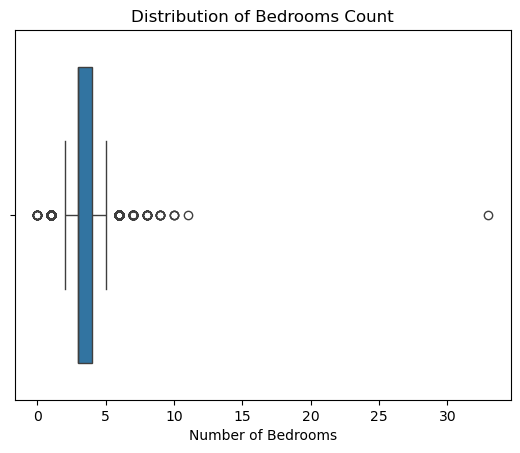

In [7]:
sns.boxplot(data=df_raw,x= "bedrooms")
plt.title("Distribution of Bedrooms Count")
plt.xlabel("Number of Bedrooms")
plt.show()

#we do some univariative analysis for checking outliers, especially the 33 bedrooms.

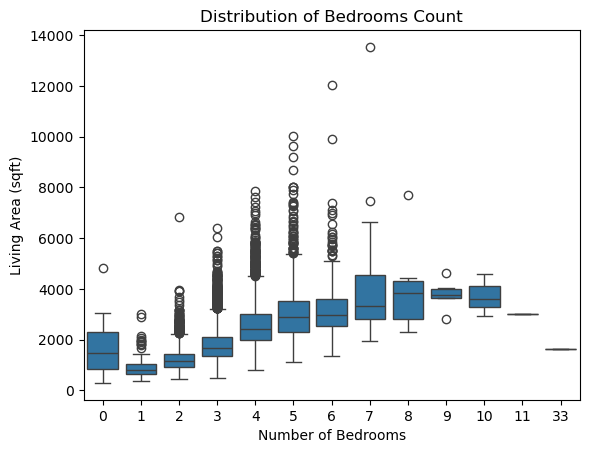

In [8]:
sns.boxplot(data=df_raw,x= "bedrooms", y= "sqft_living")
plt.title("Distribution of Bedrooms Count")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Living Area (sqft)")
plt.show()

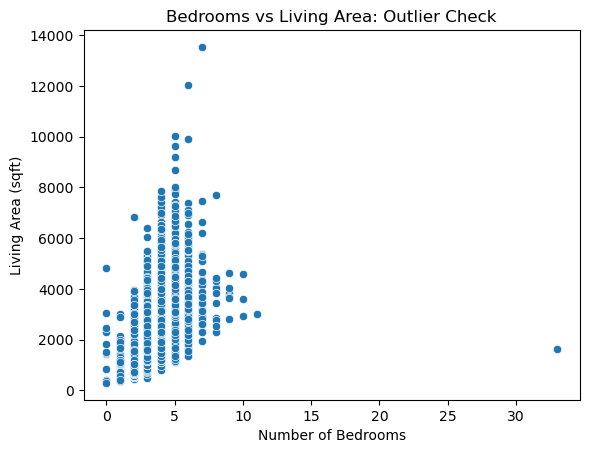

In [9]:
sns.scatterplot(data=df_raw, x= "bedrooms", y= "sqft_living")
plt.title("Bedrooms vs Living Area: Outlier Check")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Living Area (sqft)")
plt.show()

#Using bivariative analysis to compare the number and distribution of bedrooms in relations of the sqfts of the properties.

In [10]:
corr_bedrooms = df_raw["bedrooms"].corr(df_raw["sqft_living"])
print(f"Correlación bedrooms vs sqft_living: {corr_bedrooms:.3f}")

Correlación bedrooms vs sqft_living: 0.577


As confirmed 33 bedrooms in a 1620 sqft flat it's impossible, so we will erase that line, cause we don't have any way to confirm if it's a typo mistake, neither supouse that it's 3.

In [11]:
df = df[df["bedrooms"] != 33] #we start to use the df (the clean one which will be the definitive to use)

In [12]:
df_raw.shape, df.shape #to confirm the deteletion

((21613, 21), (21612, 21))

In [13]:
corr_bedrooms = df["bedrooms"].corr(df["sqft_living"])
print(f"Correlación bedrooms vs sqft_living: {corr_bedrooms:.3f}")

Correlación bedrooms vs sqft_living: 0.591


The correlation in the clean df it's a bit higher cause we eliminate the 33 outlier.

We also can realise are some houses which are having 0 bedrooms, which is posible in houses kind of studios, lofts, etc. So lets check the the rest of data of those structures:

In [14]:

cero_bedrooms = df[df["bedrooms"] == 0]

cero_bedrooms


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
875,6306400140,20140612T000000,1095000.0,0,0.00,3064,4764,3.5,0,2,...,7,3064,0,1990,0,98102,47.6362,-122.322,2360,4000
3119,3918400017,20150205T000000,380000.0,0,0.00,1470,979,3.0,0,2,...,8,1470,0,2006,0,98133,47.7145,-122.356,1470,1399
3467,1453602309,20140805T000000,288000.0,0,1.50,1430,1650,3.0,0,0,...,7,1430,0,1999,0,98125,47.7222,-122.290,1430,1650
4868,6896300380,20141002T000000,228000.0,0,1.00,390,5900,1.0,0,0,...,4,390,0,1953,0,98118,47.5260,-122.261,2170,6000
6994,2954400190,20140624T000000,1295650.0,0,0.00,4810,28008,2.0,0,0,...,12,4810,0,1990,0,98053,47.6642,-122.069,4740,35061
8477,2569500210,20141117T000000,339950.0,0,2.50,2290,8319,2.0,0,0,...,8,2290,0,1985,0,98042,47.3473,-122.151,2500,8751
8484,2310060040,20140925T000000,240000.0,0,2.50,1810,5669,2.0,0,0,...,7,1810,0,2003,0,98038,47.3493,-122.053,1810,5685
9773,3374500520,20150429T000000,355000.0,0,0.00,2460,8049,2.0,0,0,...,8,2460,0,1990,0,98031,47.4095,-122.168,2520,8050
9854,7849202190,20141223T000000,235000.0,0,0.00,1470,4800,2.0,0,0,...,7,1470,0,1996,0,98065,47.5265,-121.828,1060,7200
12653,7849202299,20150218T000000,320000.0,0,2.50,1490,7111,2.0,0,0,...,7,1490,0,1999,0,98065,47.5261,-121.826,1500,4675


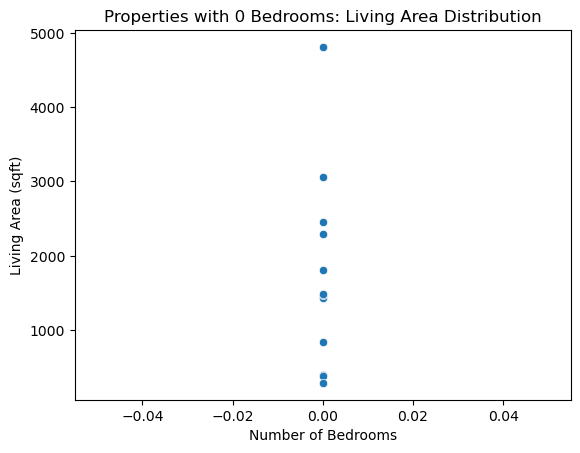

In [15]:

sns.scatterplot(data= cero_bedrooms ,x= "bedrooms", y= "sqft_living")
plt.title("Properties with 0 Bedrooms: Living Area Distribution")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Living Area (sqft)")
plt.show()

As we can see, the properties with "0" bedrooms data are not consistent, cause we could expect small properties in term of sqft and they are many (5 at least of 13) that break the theory of types studios/loft structures.

After this analysis, we decided to delete also the lines of bedrooms "0", they are representing a very little percentage of the total sample wich probably wont affect the results but we preffer to eradicate the uncertainties.

In [16]:
df = df[df["bedrooms"] != 0]

In [17]:
df_raw.shape, df.shape #to confirm the deteletion

((21613, 21), (21599, 21))

We also can see that "bathrooms" column has not integers values but floats, so lets dive into that:

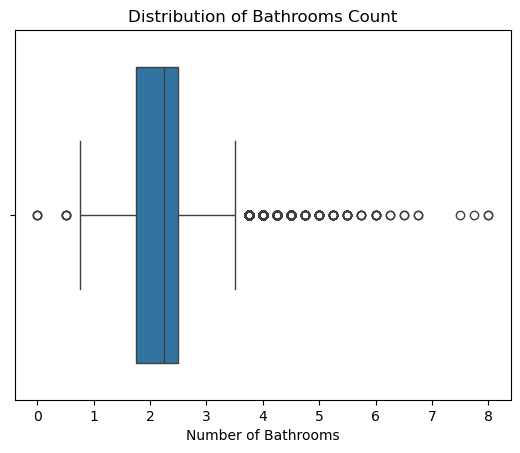

In [18]:
sns.boxplot(data=df, x= "bathrooms")
plt.title("Distribution of Bathrooms Count")
plt.xlabel("Number of Bathrooms")
plt.show()


#we do some univariative analysis to check the column of bathrooms

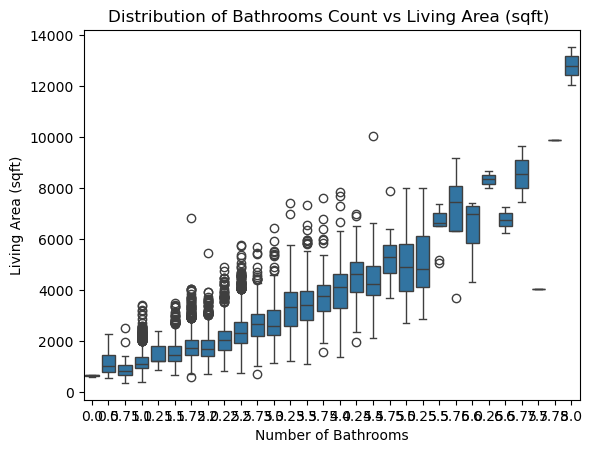

In [19]:
sns.boxplot(data=df, x= "bathrooms", y= "sqft_living")
plt.title("Distribution of Bathrooms Count vs Living Area (sqft) ")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Living Area (sqft)")
plt.show()

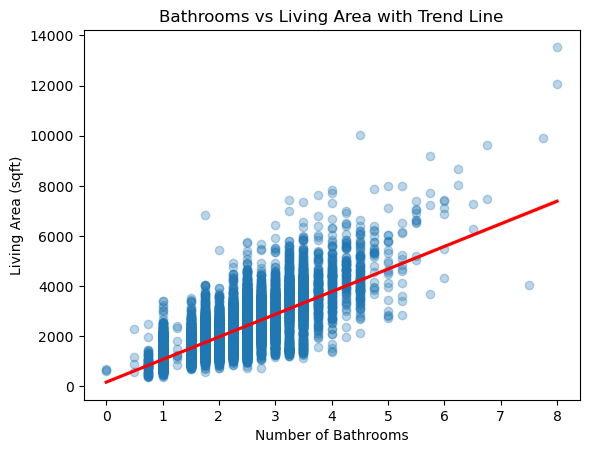

In [20]:
sns.regplot(data= df, x="bathrooms", y="sqft_living", scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Bathrooms vs Living Area with Trend Line")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Living Area (sqft)")
plt.show()

#Using bivariative analysis to compare the number and distribution of bathrooms in relations of the sqfts of the properties.

In [21]:
corr_bathrooms = df["bathrooms"].corr(df["sqft_living"])
print(f"Correlación bathrooms vs sqft_living: {corr_bathrooms:.3f}")

Correlación bathrooms vs sqft_living: 0.756


The scatterplot shows an incresing tendecy between the size of the property and the number of bathrooms which we could understand as realistic one. 

For this reason, we will keep the bathrooms column as it is, since the values appear consistent with the property size.

Lets do some other comparations:

In [22]:
df[df["sqft_living"] == 13540.00]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
12777,1225069038,20140505T000000,2280000.0,7,8.0,13540,307752,3.0,0,4,...,12,9410,4130,1999,0,98053,47.6675,-121.986,4850,217800


We found an outlier which is an exception in all the DF, this house is 13540 sqft, which can be diffucult to find, buitbut checking other features as price (2.2M) or surface above and basement (9410 + 4130 = 13540) , we can asume that in fact is a really BIG HOUSE. The only concerning it's that the documentantion says the grade is from 1 to 11, but this house is 12 and the max value y grade it's 13.

In [23]:
df["grade"].value_counts().sort_index()

grade
3        3
4       27
5      242
6     2038
7     8974
8     6065
9     2615
10    1134
11     399
12      89
13      13
Name: count, dtype: int64

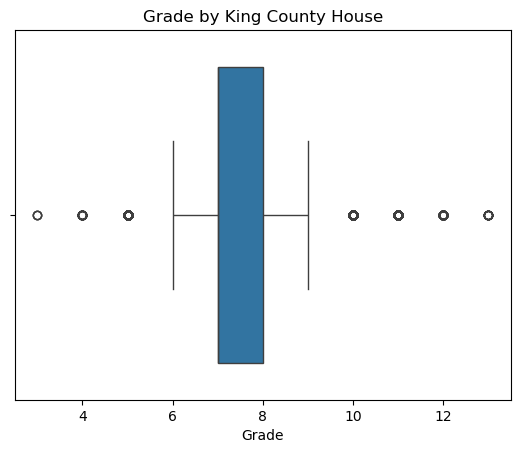

In [24]:
sns.boxplot(data=df,x= "grade")
plt.title("Grade by King County House")
plt.xlabel("Grade")
plt.show()

In [25]:
df[df["grade"] == 13]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
4411,2470100110,20140804T000000,5570000.0,5,5.75,9200,35069,2.0,0,0,...,13,6200,3000,2001,0,98039,47.6289,-122.233,3560,24345
4811,9831200500,20150304T000000,2479000.0,5,3.75,6810,7500,2.5,0,0,...,13,6110,700,1922,0,98102,47.6285,-122.322,2660,7500
5451,7237501190,20141010T000000,1780000.0,4,3.25,4890,13402,2.0,0,0,...,13,4890,0,2004,0,98059,47.5303,-122.131,5790,13539
6041,1725059316,20141120T000000,2385000.0,4,4.00,6330,13296,2.0,0,2,...,13,4900,1430,2000,0,98033,47.6488,-122.201,2200,9196
7035,853200010,20140701T000000,3800000.0,5,5.50,7050,42840,1.0,0,2,...,13,4320,2730,1978,0,98004,47.6229,-122.220,5070,20570
7252,6762700020,20141013T000000,7700000.0,6,8.00,12050,27600,2.5,0,3,...,13,8570,3480,1910,1987,98102,47.6298,-122.323,3940,8800
7907,1068000375,20140923T000000,3200000.0,6,5.00,7100,18200,2.5,0,0,...,13,5240,1860,1933,2002,98199,47.6427,-122.408,3130,6477
9254,9208900037,20140919T000000,6885000.0,6,7.75,9890,31374,2.0,0,4,...,13,8860,1030,2001,0,98039,47.6305,-122.240,4540,42730
10373,3303850390,20141212T000000,2983000.0,5,5.50,7400,18898,2.0,0,3,...,13,6290,1110,2001,0,98006,47.5431,-122.112,6110,26442
13411,2426039123,20150130T000000,2415000.0,5,4.75,7880,24250,2.0,0,2,...,13,7880,0,1996,0,98177,47.7334,-122.362,2740,10761


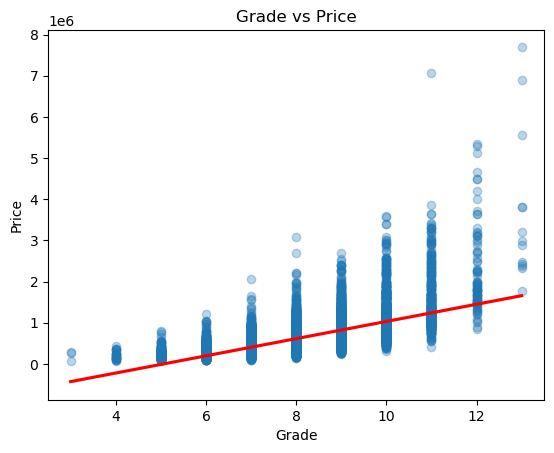

In [26]:
sns.regplot(data= df, x= "grade", y= "price", scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Grade vs Price")
plt.xlabel("Grade")
plt.ylabel("Price")
plt.show()

In [27]:
corr_grade_price = df["grade"].corr(df["price"])
print(f"Correlación grade vs price: {corr_grade_price:.3f}")

Correlación grade vs price: 0.668


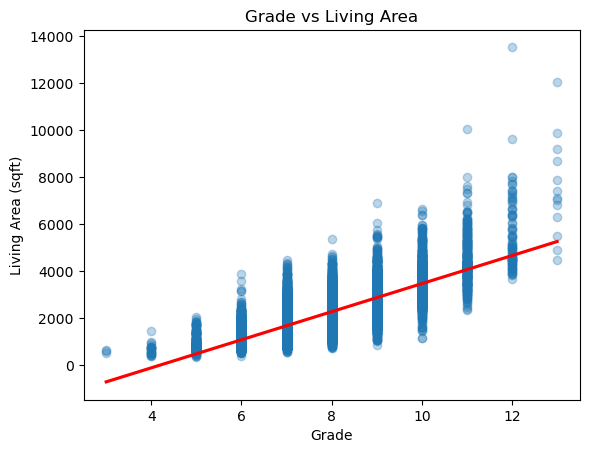

In [28]:
sns.regplot(data= df, x= "grade", y= "sqft_living", scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Grade vs Living Area")
plt.xlabel("Grade")
plt.ylabel("Living Area (sqft)")
plt.show()

In [29]:
corr_grade_living_area = df["grade"].corr(df["sqft_living"])
print(f"Correlación grade vs sqft_living: {corr_grade_living_area:.3f}")

Correlación grade vs sqft_living: 0.763


In conclusion, we asume the documentation it's not updated, cause we have some properties in grade 12 and 13 (102 properties in total) . This grades are supported by prices and  living sqft, as the graphics shows ascending trends in relation with the grades. So we decided to keep both grade 12 and 13.

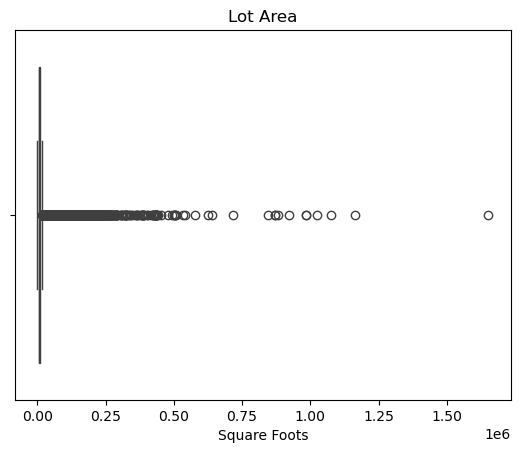

In [30]:
sns.boxplot(data=df,x= "sqft_lot")
plt.title("Lot Area")
plt.xlabel("Square Foots")
plt.show()


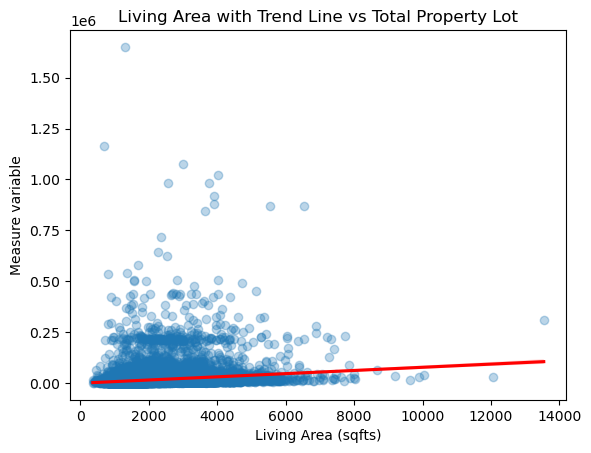

In [31]:
sns.regplot(data= df, x= "sqft_living", y= "sqft_lot", scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Living Area with Trend Line vs Total Property Lot")
plt.xlabel("Living Area (sqfts)")
plt.ylabel("Measure variable")
plt.show()

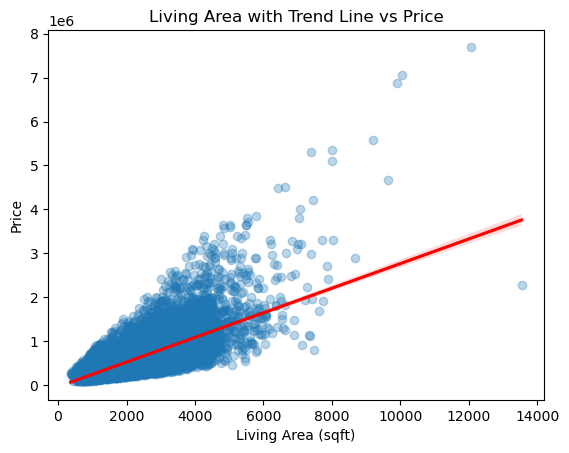

In [32]:
sns.regplot(data= df, x= "sqft_living", y= "price", scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Living Area with Trend Line vs Price")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.show()


In [33]:
corr_living_area = df["sqft_living"].corr(df["price"])
print(f"Correlación living area vs price: {corr_living_area:.3f}")

Correlación living area vs price: 0.702


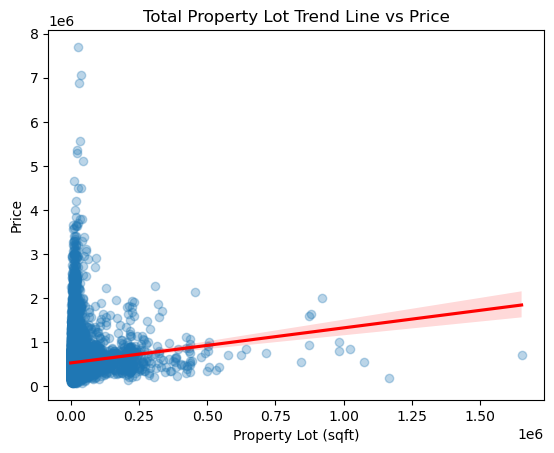

In [34]:

sns.regplot(data= df, x= "sqft_lot", y= "price", scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Total Property Lot Trend Line vs Price")
plt.xlabel("Property Lot (sqft)")
plt.ylabel("Price")
plt.show()


In [35]:
corr_lot = df["sqft_lot"].corr(df["price"])
print(f"Correlación lot area vs price: {corr_lot:.3f}")

Correlación lot area vs price: 0.090


Date we will convert it into datetime format in case that we need to acces a certain, create some new features as month and year:

In [36]:
# Convert 'date' to datetime format
df["date"] = pd.to_datetime(df["date"])

# Extract useful features from it
df["sale_year"] = df["date"].dt.year
df["sale_month"] = df["date"].dt.month

df[["date", "sale_year", "sale_month"]].head()

,date,sale_year,sale_month
0,2014-10-13,2014,10
1,2014-12-09,2014,12
2,2015-02-25,2015,2
3,2014-12-09,2014,12
4,2015-02-18,2015,2


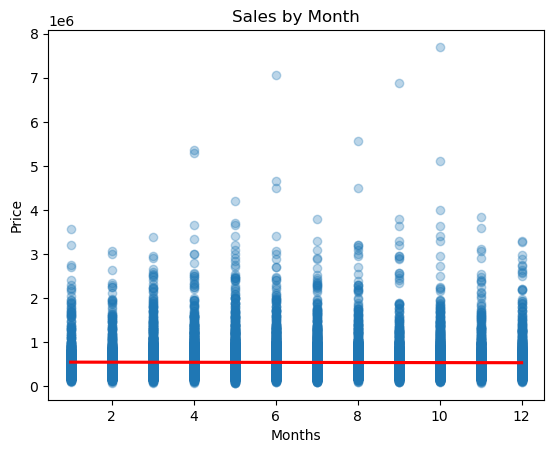

In [37]:
sns.regplot(data= df, x= "sale_month", y= "price", scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Sales by Month")
plt.xlabel("Months")
plt.ylabel("Price")
plt.show()

As we can see, living area shows a strong positive correlation with price (0.702), 
while lot size shows a very weak correlation (0.090). Although both scatterplots 
show an ascending trend line, the relationship between living area and price is 
clearly much stronger and more consistent than the one between lot size and price.

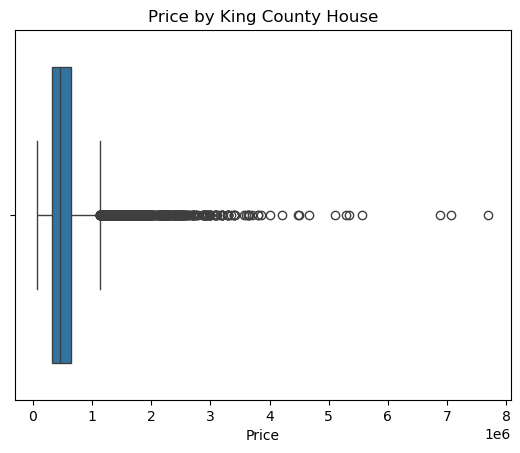

In [38]:
sns.boxplot(data=df,x= "price")
plt.title("Price by King County House")
plt.xlabel("Price")
plt.show()

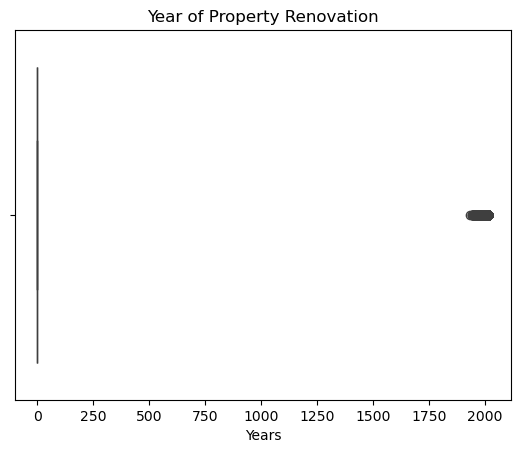

In [39]:
sns.boxplot(data=df,x= "yr_renovated")
plt.title("Year of Property Renovation")
plt.xlabel("Years")
plt.show()

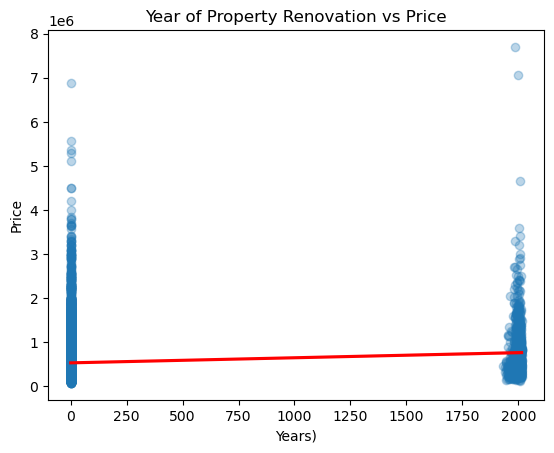

In [40]:
sns.regplot(data= df, x= "yr_renovated", y= "price", scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Year of Property Renovation vs Price")
plt.xlabel("Years)")
plt.ylabel("Price")
plt.show()

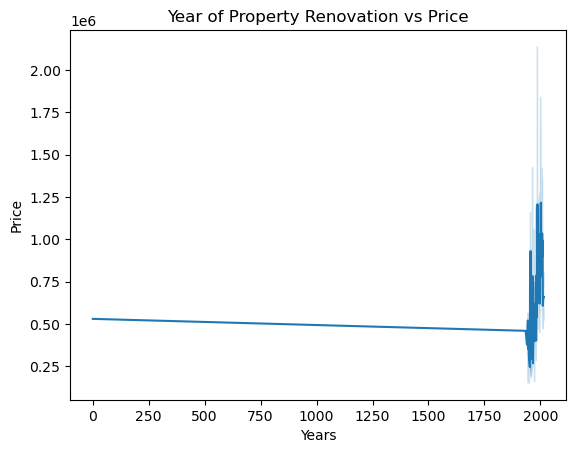

In [41]:
sns.lineplot(data= df, x= "yr_renovated", y= "price")
plt.title("Year of Property Renovation vs Price")
plt.xlabel("Years")
plt.ylabel("Price")
plt.show()

The `yr_renovated` column mixes actual renovation years with a large number of 
zeros representing properties that were never renovated. Treating 0 as a literal 
year would introduce a false extreme value, distorting any relationship the model 
could learn from this feature.

To address this, we created a new binary feature `was_renovated` (1 = renovated, 
0 = never renovated), which captures the relevant signal without the distortion 
of treating "not renovated" as a numeric year. We keep the original `yr_renovated` 
column for reference, but `was_renovated` will be the feature used going forward.

In [42]:
df["was_renovated"] = (df["yr_renovated"] != 0).astype(int)

In [43]:
df["was_renovated"].head()

0    0
1    1
2    0
3    0
4    0
Name: was_renovated, dtype: int64

In [44]:
df["years_since_renovation"] = df.apply(
    lambda row: row["sale_year"] - row["yr_renovated"] if row["yr_renovated"] != 0 else 0,
    axis=1
)

In [45]:
df["years_since_renovation"].head()

0     0
1    23
2     0
3     0
4     0
Name: years_since_renovation, dtype: int64

The id column is not giving any usefull information to the model as it's just an identificator for King County, so we will erase it:

In [46]:
df = df.drop("id", axis = 1)

In [47]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,was_renovated,years_since_renovation
0,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,0,98178,47.5112,-122.257,1340,5650,2014,10,0,0
1,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,1991,98125,47.7210,-122.319,1690,7639,2014,12,1,23
2,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,3,...,0,98028,47.7379,-122.233,2720,8062,2015,2,0,0
3,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,0,98136,47.5208,-122.393,1360,5000,2014,12,0,0
4,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,0,98074,47.6168,-122.045,1800,7503,2015,2,0,0


Lets confirm about the duplicates:

In [48]:
df.duplicated().sum()

np.int64(0)

No duplicates were found!

Lets check correlations between variables:

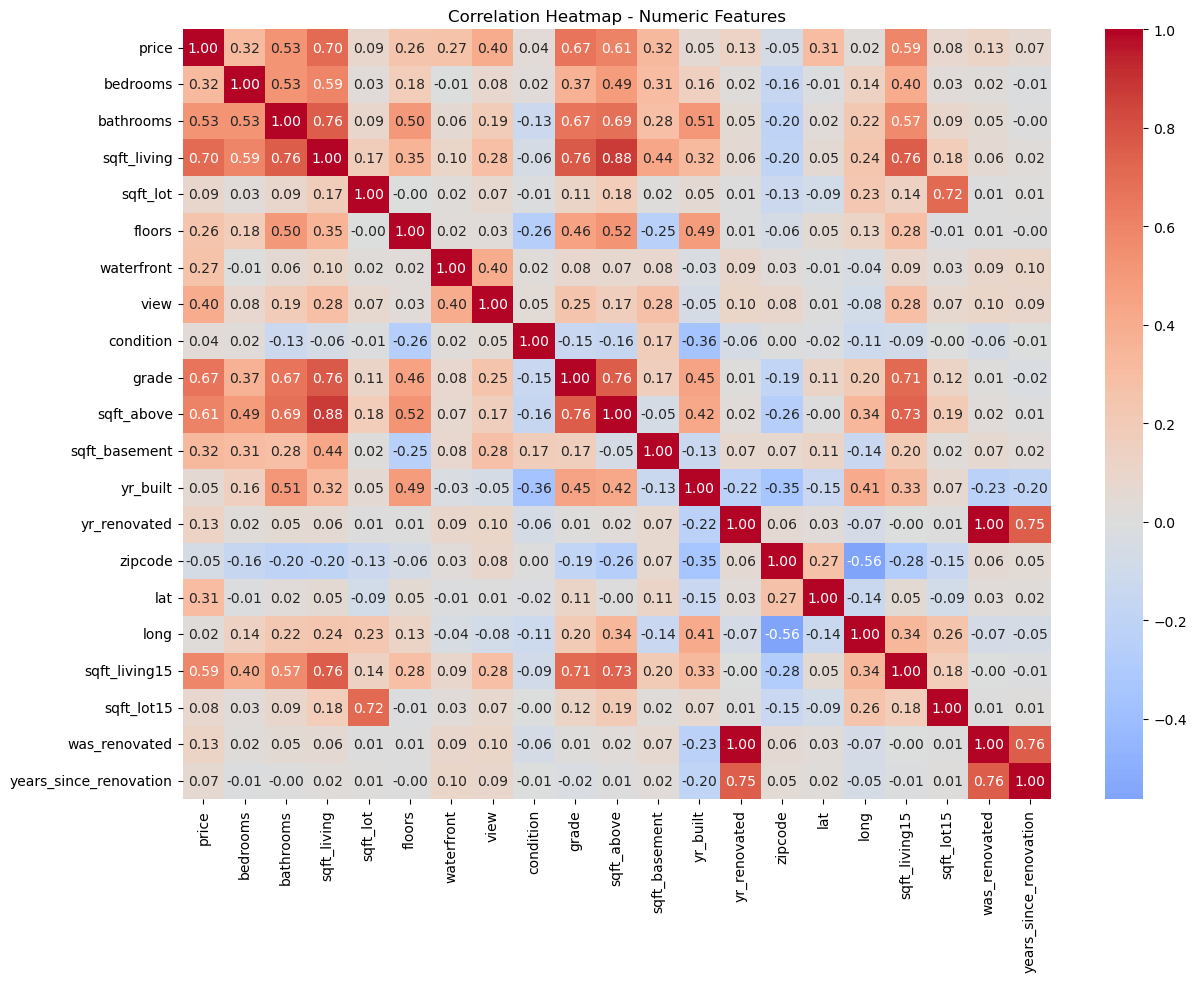

In [49]:
# Select only numeric columns (excludes 'date' if still datetime type)
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Numeric Features")
plt.show()

As we know our target will be "price", so we can see the best correlations are with "sqft_living" and "grade" (0.70 and 0.67)

In [50]:
# Check if sqft_above + sqft_basement always equals sqft_living
df["check_sum"] = df["sqft_above"] + df["sqft_basement"]
df["matches"] = df["check_sum"] == df["sqft_living"]

print(df["matches"].value_counts())
print(f"\nMismatches: {(~df['matches']).sum()} out of {len(df)} rows")

# If there are mismatches, inspect them
df[~df["matches"]][["sqft_living", "sqft_above", "sqft_basement", "check_sum"]].head(10)

matches
True    21599
Name: count, dtype: int64

Mismatches: 0 out of 21599 rows


,sqft_living,sqft_above,sqft_basement,check_sum


In [51]:
df = df.drop(columns=["check_sum", "matches"])

In [52]:
df = df.drop("yr_renovated", axis = 1)

In [53]:
df.head(1)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_built,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,was_renovated,years_since_renovation
0,2014-10-13,221900.0,3,1.0,1180,5650,1.0,0,0,3,...,1955,98178,47.5112,-122.257,1340,5650,2014,10,0,0


In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["zipcode_encoded"] = le.fit_transform(df["zipcode"])

df[["zipcode", "zipcode_encoded"]].head()

,zipcode,zipcode_encoded
0,98178,66
1,98125,55
2,98028,16
3,98136,58
4,98074,37


In [55]:
df = df.drop(columns=["zipcode"])

In [56]:
df.head(1)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_built,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,was_renovated,years_since_renovation,zipcode_encoded
0,2014-10-13,221900.0,3,1.0,1180,5650,1.0,0,0,3,...,1955,47.5112,-122.257,1340,5650,2014,10,0,0,66


In [57]:
df.dtypes

date                      datetime64[ns]
price                            float64
bedrooms                           int64
bathrooms                        float64
sqft_living                        int64
sqft_lot                           int64
floors                           float64
waterfront                         int64
view                               int64
condition                          int64
grade                              int64
sqft_above                         int64
sqft_basement                      int64
yr_built                           int64
lat                              float64
long                             float64
sqft_living15                      int64
sqft_lot15                         int64
sale_year                          int32
sale_month                         int32
was_renovated                      int64
years_since_renovation             int64
zipcode_encoded                    int64
dtype: object

In [58]:
df = df.drop(columns=["date"])

In [59]:
df.dtypes

price                     float64
bedrooms                    int64
bathrooms                 float64
sqft_living                 int64
sqft_lot                    int64
floors                    float64
waterfront                  int64
view                        int64
condition                   int64
grade                       int64
sqft_above                  int64
sqft_basement               int64
yr_built                    int64
lat                       float64
long                      float64
sqft_living15               int64
sqft_lot15                  int64
sale_year                   int32
sale_month                  int32
was_renovated               int64
years_since_renovation      int64
zipcode_encoded             int64
dtype: object

# Spliting the DataSet

In [61]:
X = df.drop(columns=["price"])
y = df["price"]

print(X.shape, y.shape)

(21599, 21) (21599,)


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(17279, 21) (4320, 21) (17279,) (4320,)


## Linear Regression

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression:")
print(f"R²: {r2_score(y_test, y_pred_lr):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")

Linear Regression:
R²: 0.710
MAE: 126343.52


## KNN

In [64]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN Regressor:")
print(f"R²: {r2_score(y_test, y_pred_knn):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_knn):.2f}")

KNN Regressor:
R²: 0.790
MAE: 93666.91


As baseline models, we trained Linear Regression and KNN Regressor on the cleaned 
and encoded dataset.

Linear Regression achieved an R² of 0.710 and MAE of $126,343.52, meaning the 
model explains about 71% of the variance in price, with an average prediction 
error of over $126K per house.

KNN Regressor performed noticeably better, with an R² of 0.790 and MAE of $93,666.91. 
This suggests that the relationship between features and price is not purely linear — 
KNN, which makes no linear assumptions, captures these patterns more effectively. 
This is consistent with what we observed during EDA (e.g., the non-linear-looking 
relationship between `grade` and `price`).

These baseline results will serve as the reference point for evaluating our 
ensemble models (Random Forest, Decision Tree, Gradient Boosting/XGBoost).

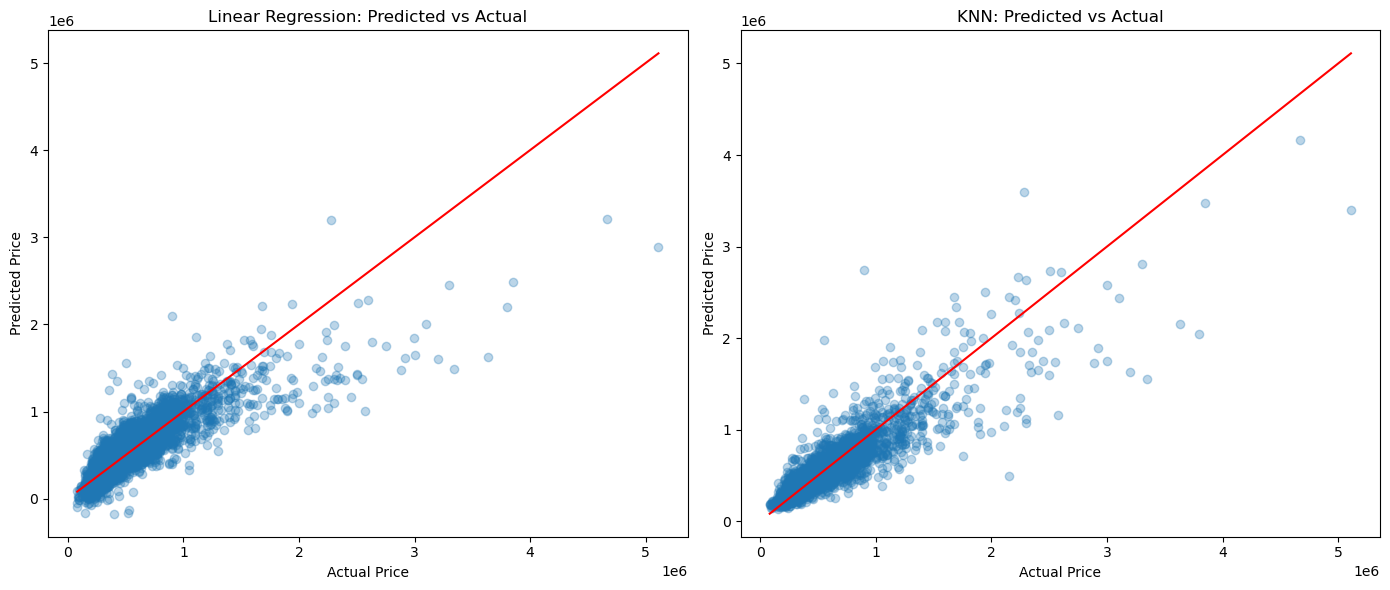

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
axes[0].set_title("Linear Regression: Predicted vs Actual")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")

# KNN
axes[1].scatter(y_test, y_pred_knn, alpha=0.3)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
axes[1].set_title("KNN: Predicted vs Actual")
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")

plt.tight_layout()
plt.show()

The predicted vs actual plots confirm the metrics: KNN predictions cluster more 
tightly around the perfect-prediction line, especially in the $0-2M range, while 
Linear Regression shows more scatter and a tendency to underestimate mid-range prices.

Both models struggle with high-value properties (>$2.5M), consistently 
underpredicting their

## Random Forest Regression

In [66]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest:")
print(f"R²: {r2_score(y_test, y_pred_rf):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")

Random Forest:
R²: 0.882
MAE: 68356.85


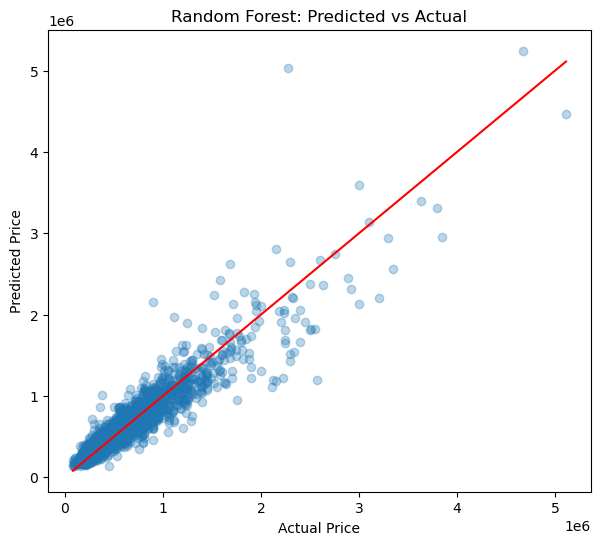

In [67]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.title("Random Forest: Predicted vs Actual")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

Random Forest clearly outperforms both baseline models:

| Model              | R²    | MAE          |
|---------------------|-------|--------------|
| Linear Regression    | 0.710 | $126,343.52  |
| KNN Regressor         | 0.790 | $93,666.91   |
| Random Forest         | 0.882 | $68,356.85   |

This confirms our earlier hypothesis: the relationship between features and price 
is non-linear, and Random Forest's ability to capture complex feature interactions 
(without manually engineering them) gives it a clear advantage.

The predicted vs actual plot shows tight clustering around the ideal line for most 
properties, especially below $2M. However, high-value properties (>$2.5M) remain 
underpredicted across all three models, likely due to their underrepresentation 
in the dataset rather than a model-specific limitation.

In [69]:
# Train vs test (para detectar overfitting en RF base)
y_pred_rf_train = rf.predict(X_train)
print(f"Random Forest - Train R²: {r2_score(y_train, y_pred_rf_train):.3f}")
print(f"Random Forest - Test R²: {r2_score(y_test, y_pred_rf):.3f}")

Random Forest - Train R²: 0.983
Random Forest - Test R²: 0.882


In [70]:
# Prueba de multicolinealidad: RF sin sqft_above/sqft_basement
X_train_reduced = X_train.drop(columns=["sqft_above", "sqft_basement"])
X_test_reduced = X_test.drop(columns=["sqft_above", "sqft_basement"])

rf_reduced = RandomForestRegressor(random_state=42)
rf_reduced.fit(X_train_reduced, y_train)
y_pred_rf_reduced = rf_reduced.predict(X_test_reduced)

print("Random Forest (sin sqft_above/sqft_basement):")
print(f"R²: {r2_score(y_test, y_pred_rf_reduced):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf_reduced):.2f}")

Random Forest (sin sqft_above/sqft_basement):
R²: 0.879
MAE: 68786.50


The base Random Forest shows a train R² of 0.983 vs a test R² of 0.882 — a gap 
that signals some overfitting, motivating the hyperparameter tuning below.

We also tested removing `sqft_above` and `sqft_basement` (mathematically redundant 
with `sqft_living`) to address the multicollinearity identified earlier. This 
slightly *worsened* performance (R² 0.882 → 0.879, MAE $68,356.85 → $68,786.50), 
confirming that Random Forest handles correlated features well and that each 
column still contributes useful independent signal. We kept both variables.

In [68]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV R² score:", rf_grid.best_score_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best CV R² score: 0.8782329823540964


In [71]:
best_rf = rf_grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("Random Forest (Tuned):")
print(f"R²: {r2_score(y_test, y_pred_best_rf):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_best_rf):.2f}")

Random Forest (Tuned):
R²: 0.880
MAE: 68120.24


In [72]:
y_pred_best_rf_train = best_rf.predict(X_train)
print(f"Random Forest Tuned - Train R²: {r2_score(y_train, y_pred_best_rf_train):.3f}")
print(f"Random Forest Tuned - Test R²: {r2_score(y_test, y_pred_best_rf):.3f}")

Random Forest Tuned - Train R²: 0.978
Random Forest Tuned - Test R²: 0.880


In [73]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "KNN Regressor", "Random Forest (Base)", "Random Forest (Tuned)"],
    "R²": [0.710, 0.790, 0.882, 0.880],
    "MAE": [126343.52, 93666.91, 68356.85, 68120.24]
})

results

,Model,R²,MAE
0,Linear Regression,0.710,126343.52
1,KNN Regressor,0.790,93666.91
2,Random Forest (Base),0.882,68356.85
3,Random Forest (Tuned),0.880,68120.24


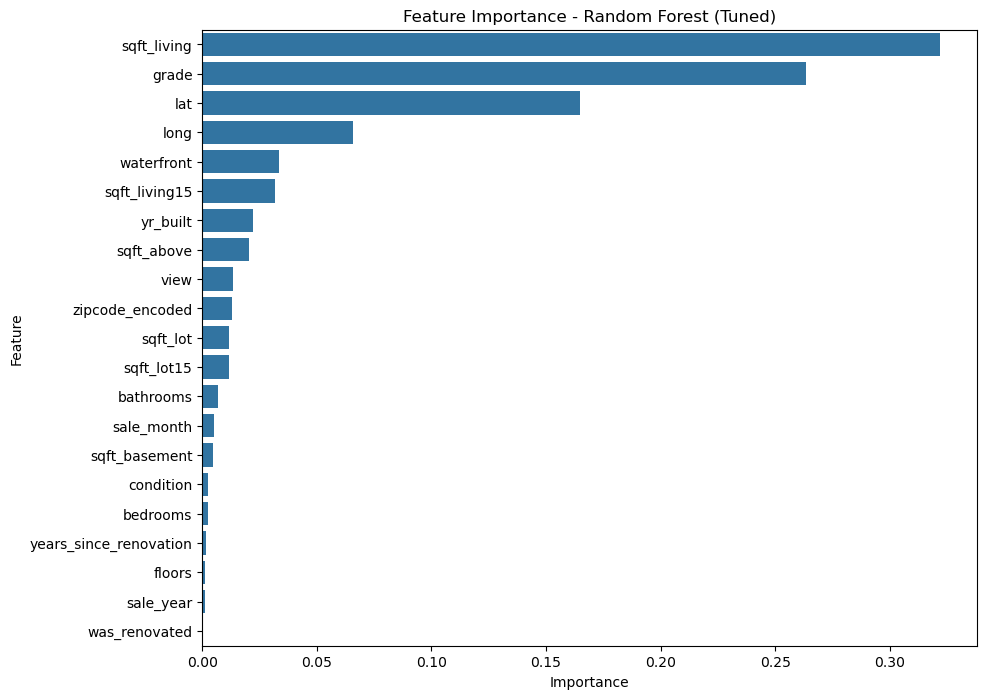

,feature,importance
2,sqft_living,0.321956
8,grade,0.263606
12,lat,0.164766
13,long,0.065784
5,waterfront,0.033348
14,sqft_living15,0.031736
11,yr_built,0.022076
9,sqft_above,0.020311
6,view,0.013367
20,zipcode_encoded,0.012884


In [74]:
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances, x="importance", y="feature")
plt.title("Feature Importance - Random Forest (Tuned)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

importances

## Model Comparison

| Model | R² | MAE |
|---|---|---|
| Linear Regression | 0.710 | $126,343.52 |
| KNN Regressor | 0.790 | $93,666.91 |
| Random Forest (Base) | 0.882 | $68,356.85 |
| Random Forest (Tuned) | 0.880 | $68,120.24 |

Random Forest (Tuned) achieves the lowest MAE, though its R² on this particular 
test split is marginally lower than the base model (0.880 vs 0.882) — expected, 
since GridSearchCV optimizes for average cross-validation performance, not this 
specific test set. We select Random Forest (Tuned) as our final model given its 
lower MAE and more robust hyperparameters.

## Feature Importance

The three most influential features are `sqft_living`, `grade`, and `lat`. 
Notably, `lat` ranks far higher than its linear correlation with price would 
suggest — this confirms our earlier hypothesis that location has a non-linear 
relationship with price (certain areas command premium prices independent of a 
simple geographic gradient), which Random Forest captures but linear correlation 
cannot detect. `zipcode_encoded`, despite representing similar location information, 
ranks much lower — likely because Label Encoding assigns arbitrary numeric order 
to zipcodes, making it less useful for splits than the continuous `lat`/`long` values.

## Further Improvement — Log-Transformed Target

Our teammates found that log-transforming `price` was the most effective 
preprocessing step across their models. We tested the same approach on our 
tuned Random Forest.

In [80]:

# Transformar el target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Entrenar Random Forest con el target transformado (mismos hiperparámetros que el tuned)
rf_log = RandomForestRegressor(
    max_depth=30, min_samples_split=5, min_samples_leaf=1, n_estimators=300,
    random_state=42
)
rf_log.fit(X_train, y_train_log)

# Predecir en escala log, luego revertir con expm1
y_pred_log = rf_log.predict(X_test)
y_pred_rf_log = np.expm1(y_pred_log)

print("Random Forest (log-transformed price):")
print(f"R²: {r2_score(y_test, y_pred_rf_log):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf_log):.2f}")

Random Forest (log-transformed price):
R²: 0.887
MAE: 68493.53


In [78]:
y_pred_log_train = rf_log.predict(X_train)
y_pred_rf_log_train = np.expm1(y_pred_log_train)

print(f"Train R² (log price): {r2_score(y_train, y_pred_rf_log_train):.3f}")
print(f"Test R² (log price): {r2_score(y_test, y_pred_rf_log):.3f}")

Train R² (log price): 0.97
Test R² (log price): 0.89


In [77]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "KNN Regressor", "Random Forest (Base)", 
              "Random Forest (Tuned)", "Random Forest (Tuned + log price)"],
    "R²": [0.710, 0.790, 0.882, 0.880, 0.887],
    "MAE": [126343.52, 93666.91, 68356.85, 68120.24, 68493.53]
})

results

,Model,R²,MAE
0,Linear Regression,0.710,126343.52
1,KNN Regressor,0.790,93666.91
2,Random Forest (Base),0.882,68356.85
3,Random Forest (Tuned),0.880,68120.24
4,Random Forest (Tuned + log price),0.887,68493.53


The log-transform improved R² (0.880 → 0.887) and reduced the train-test 
overfitting gap (0.978/0.880 → 0.972/0.887), consistent with our teammates' 
findings on other models. MAE in dollar terms rose slightly ($68,120.24 → 
$68,493.53) — log-transforming optimizes for proportional error, trading a 
bit of accuracy on mid-range homes for better relative performance on the 
underrepresented high-value segment.

Given the improvement in R² and generalization, we select **Random Forest 
(Tuned + log price)** as our final model.

# IronKaggle Project — Final Summary

## Project Overview

This project builds a regression model to predict house sale prices in King County (Seattle area) based on property characteristics, using the King County House Sales dataset (21,613 rows, 21 original features). The assigned model for this notebook is **Random Forest Regressor**, compared against Linear Regression and KNN Regressor as baselines.

---

## 1. Data Loading & Exploration

The dataset was loaded via `pandas.read_csv()` and explored using `.shape`, `.info()`, `.describe()`, and `.head()`. No missing values were found across any column. `date` was initially loaded as an object (string) type and later converted to datetime.

---

## 2. Data Cleaning

A consistent process was applied to every suspicious variable: **detect → cross-check with a related variable → decide → document.**

| Variable | Finding | Decision |
|---|---|---|
| `bedrooms` | One row with 33 bedrooms in a 1,620 sqft home — physically impossible, confirmed via cross-check with `sqft_living` | Row dropped |
| `bedrooms` | 13 rows with 0 bedrooms; sqft_living ranged from 290 to 4,810, contradicting the "studio/loft" hypothesis for the larger cases | Rows dropped (0.06% of data, negligible impact) |
| `bathrooms` | Fractional values (1.75, 2.25...) confirmed as a real US real-estate convention, not errors. Max of 8 baths follows the general size trend (no outliers breaking the pattern) | Kept as-is |
| `sqft_living` | Max value of 13,540 sqft confirmed internally consistent (`sqft_above` + `sqft_basement` = `sqft_living` exactly; price, lot size, and room counts all proportionate) | Kept as valid (real large property) |
| `grade` | External documentation stated a 1–11 scale, but data showed values up to 13 (89 rows at grade 12, 13 rows at grade 13) — confirmed as a real, consistent range via `value_counts()` and correlation with price/sqft_living | Documentation treated as outdated; full observed range (3–13) kept |
| `sqft_lot` | Highly right-skewed distribution (max ~1.65M sqft); very weak correlation with price (0.090) | Kept as-is (real variability across rural/urban lots) |
| `yr_renovated` | Mixed real renovation years with a large number of zeros representing "never renovated" — treating 0 as a literal year would distort any numeric relationship | Replaced with `was_renovated` (binary) and `years_since_renovation`; original column dropped |
| `id` | Unique identifier with no predictive value | Dropped |
| Duplicates | Checked via `.duplicated().sum()` | None found |

---

## 3. Feature Engineering

- `sale_year`, `sale_month` — extracted from `date` (then `date` dropped, as raw timestamps aren't usable by the model)
- `was_renovated` — binary flag (1 = renovated, 0 = never renovated)
- `years_since_renovation` — years between renovation and sale (0 if never renovated)
- `zipcode_encoded` — Label Encoding applied to `zipcode` (acceptable for tree-based models, which don't assume numeric order has meaning)

---

## 4. Correlation Analysis (EDA)

Key findings from Pearson correlation against `price`:

- **`sqft_living`**: 0.702 (strong)
- **`grade`**: 0.668 (strong)
- **`sqft_lot`**: 0.090 (very weak)

A full correlation heatmap was generated across all numeric features to identify multicollinearity, confirming the expected structural relationship `sqft_above + sqft_basement = sqft_living` (verified exactly across 100% of rows, 0 mismatches).

---

## 5. Encoding

- `waterfront`, `view` — already binary, no encoding needed
- `condition`, `grade` — ordinal, kept as numeric (tree-based models split on order naturally, no One-Hot needed)
- `zipcode` — Label Encoded (`zipcode_encoded`); `lat`/`long` were retained alongside it to preserve continuous geographic signal

---

## 6. Modeling

### Baseline Models

| Model | R² | MAE |
|---|---|---|
| Linear Regression | 0.710 | $126,343.52 |
| KNN Regressor (scaled features) | 0.790 | $93,666.91 |

KNN outperforming Linear Regression suggested the price–feature relationship is **not purely linear**, motivating the choice of Random Forest as the primary model.

### Random Forest

| Version | R² (test) | MAE | Train R² |
|---|---|---|---|
| Base (default params) | 0.882 | $68,356.85 | 0.983 |
| Tuned (GridSearchCV) | 0.880 | $68,120.24 | 0.978 |
| **Tuned + log(price)** | **0.887** | $68,493.53 | 0.972 |

**Best hyperparameters found:** `max_depth=30`, `min_samples_split=5`, `min_samples_leaf=1`, `n_estimators=300` (Best CV R² = 0.878)

Random Forest clearly outperformed both baselines, confirming the non-linearity hypothesis. Following our teammates' finding that log-transforming `price` was the most effective preprocessing step across models, we applied the same transformation to our tuned Random Forest (`np.log1p` on the target, `np.expm1` on predictions before evaluation). This further improved R² and reduced the train-test overfitting gap (0.098 → 0.085), at the cost of a small increase in dollar-term MAE.

### Multicollinearity Check (empirical)

Removing `sqft_above` and `sqft_basement` (mathematically redundant with `sqft_living`) *slightly worsened* performance (R² 0.882 → 0.879, MAE 68,356.85 → 68,786.50), confirming Random Forest handles correlated features well and that each column still carries useful independent signal (e.g., basement presence/size).

---

## 7. Model Comparison

| Model | R² | MAE |
|---|---|---|
| Linear Regression | 0.710 | $126,343.52 |
| KNN Regressor | 0.790 | $93,666.91 |
| Random Forest (Base) | 0.882 | $68,356.85 |
| Random Forest (Tuned) | 0.880 | $68,120.24 |
| **Random Forest (Tuned + log price)** | **0.887** | $68,493.53 |

**Random Forest (Tuned + log price) was selected as our final model**, based on its highest R² and the smallest train-test gap among all Random Forest versions — indicating the best generalization. The small increase in dollar-term MAE is an acceptable trade-off, since log-transforming optimizes for proportional error rather than absolute dollar error, improving relative accuracy on the underrepresented high-value segment.

---

## 8. Feature Importance

Top drivers of predicted price, based on the tuned Random Forest's `feature_importances_`:

1. **`sqft_living`** — largest single driver, consistent with its strong linear correlation
2. **`grade`** — second largest, also consistent with EDA
3. **`lat`** — ranks far higher than its weak linear correlation would suggest, confirming that location has a **non-linear** relationship with price (specific areas command premium prices independent of a simple geographic gradient) — a pattern linear correlation cannot detect but Random Forest can
4. `long`, `waterfront`, `sqft_living15` follow with moderate importance

Notably, `zipcode_encoded` ranked low despite representing similar location information — likely because Label Encoding assigns arbitrary numeric order to zipcodes, giving the model less useful split points than the continuous `lat`/`long` values.

*(Feature importance below was extracted from the tuned Random Forest before the log-transform was applied; rankings are expected to be structurally similar, since log-transforming the target changes prediction scale but not which features drive the splits.)*

---

## Key Takeaways

- Data cleaning decisions were made using a repeatable process: cross-check with related variables, verify against external documentation when available, and weigh statistical evidence against real-world plausibility — never removing data based on a single number in isolation.
- When external documentation conflicted with the data (`grade` range), the data's internal consistency was treated as authoritative, verified empirically rather than assumed.
- Random Forest substantially outperformed linear and distance-based baselines, confirming non-linear relationships between property features and price.
- Multicollinearity was documented but not blindly resolved — its impact was tested empirically before deciding to keep the correlated features.
- Location (`lat`) proved far more predictive than its linear correlation suggested, illustrating a key limitation of Pearson correlation for EDA-only decision-making.
- Collaborating with teammates paid off directly: their finding that log-transforming `price` was the most effective preprocessing step generalized to our model too, improving R² and reducing overfitting — a reminder that model improvement isn't only an individual exercise.